In [1]:
print("Hello World")

Hello World


In [2]:
import geopandas as gpd
from pystac_client import Client
import planetary_computer as pc
import odc.stac

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace)
alberta_bbox = [-113.0, 49.5, -112.0, 50.0]

print("📡 Querying STAC API for Sentinel-2 satellite tiles over Alberta...")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=alberta_bbox,
    datetime="2025-07-10/2025-07-15",
    query={"eo:cloud_cover": {"lt": 20}}
)
items = list(search.item_collection())

if len(items) > 0:
    print(f"✅ SUCCESS! Engine is live. Found {len(items)} crystal-clear satellite tiles.")
else:
    print("❌ API connected, but no tiles matched filters.")

📡 Querying STAC API for Sentinel-2 satellite tiles over Alberta...
✅ SUCCESS! Engine is live. Found 10 crystal-clear satellite tiles.


In [3]:
import sys
import os
import pandas as pd
import xarray as xr
from geocube.api.core import make_geocube

sys.path.append(os.path.abspath("../"))
from src.data_loader import get_alberta_fields
from src.satellite_streamer import stream_satellite_cube

fields_gdf = get_alberta_fields()

ds = stream_satellite_cube(fields_gdf, start_date="2025-07-01", end_date="2025-07-31")

# Calculate NDVI so we have a metric to measure per field
#still not pulling data, just saying when we do, perfrom this calc
ds["ndvi"] = (ds["B08"] - ds["B04"]) / (ds["B08"] + ds["B04"])


Successfully initialized spatial box layer (from collab).


c:\ProgramData\miniforge3\envs\crop-engine\Lib\site-packages\pystac_client\item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


In [4]:

# 1. Create a copy of your GeoDataFrame to avoid changing the original data
fields_numeric = fields_gdf.copy()

# 2. Convert your text IDs into unique integers (categorical encoding)
# This creates a mapping: 'lethbridge_block_01' becomes 1, etc.
fields_numeric['field_id_int'] = range(1, len(fields_numeric) + 1)

# Create a lookup dictionary so you can map the integers back to text names later
id_lookup = dict(zip(fields_numeric['field_id_int'], fields_numeric['field_group_id']))
print("ID Mapping Lookup Table:", id_lookup)

# 3. Now burn the INTEGERS into the raster cube instead of the strings
field_mask = make_geocube(
    vector_data=fields_numeric,
    measurements=["field_id_int"],  # Use the new integer column!
    like=ds
)
print(field_mask)

ID Mapping Lookup Table: {1: 'lethbridge_block_01'}
<xarray.Dataset> Size: 207kB
Dimensions:       (y: 158, x: 162)
Coordinates:
  * y             (y) float64 1kB 5.515e+06 5.515e+06 ... 5.514e+06 5.514e+06
  * x             (x) float64 1kB 3.475e+05 3.475e+05 ... 3.491e+05 3.491e+05
    spatial_ref   int64 8B 0
Data variables:
    field_id_int  (y, x) float64 205kB nan nan nan nan nan ... nan nan nan nan


ds is like the raster gameboard
our field is like vector battleship.

geocube turns our vector polygon into a raster object that can be marked on the ds raster dataset with the field id (in our case 1)

then using this we can then assing ndvi values to the squares that make up the field polygon (as a raster) then do the averaging for the value

In [5]:
import numpy as np
import pandas as pd

# 1. Pull the 2D pixel grid out from geocube, fill backgrounds with 0, and match types
# This gives us a raw, predictable 2D NumPy array matrix
zone_mask_matrix = field_mask["field_id_int"].fillna(0).astype(np.int32).values

# 2. Extract our unique field IDs (ignoring the 0 background)
unique_zones = [z for z in np.unique(zone_mask_matrix) if z != 0]

zonal_results = []

print(f"Calculating zonal stats for zones: {unique_zones}...")

# 3. Iterate over each time step cleanly
for time_step in ds.time:
    # .compute() forces Xarray/Dask to load just this single timestamp snapshot into memory
    # as a raw 2D NumPy matrix, dodging all Dask and coordinate alignment errors
    ndvi_snapshot = ds.sel(time=time_step).ndvi.compute().values
    
    # 4. Use pure NumPy boolean masking to find the averages
    for zone_id in unique_zones:
        # Create a boolean array where pixels equal our specific field ID
        pixel_selector = (zone_mask_matrix == zone_id)
        
        # Extract those matching pixels out of our NDVI image snapshot
        zone_pixels = ndvi_snapshot[pixel_selector]
        
        # Calculate the mean, filtering out any random NaNs safely
        zone_mean = np.nanmean(zone_pixels) if len(zone_pixels) > 0 else np.nan
        
        # Append our row structure
        zonal_results.append({
            "zone": zone_id,
            "mean": zone_mean,
            "date": time_step.values,
            "field_name": id_lookup.get(zone_id, f"Field_{zone_id}")
        })

# 5. Instantly build the final pandas data frame
field_timeseries_df = pd.DataFrame(zonal_results)

print("\n--- Success! Zonal Extraction Complete ---")
print(field_timeseries_df.head())

Calculating zonal stats for zones: [np.int32(1)]...

--- Success! Zonal Extraction Complete ---
   zone      mean                    date           field_name
0     1  0.721817 2025-07-01 18:29:41.025  lethbridge_block_01
1     1  0.728082 2025-07-11 18:29:41.025  lethbridge_block_01
2     1  0.382414 2025-07-29 18:39:19.024  lethbridge_block_01
3     1  0.307564 2025-07-31 18:29:41.025  lethbridge_block_01


In [6]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:      (y: 158, x: 162, time: 4)
Coordinates:
  * y            (y) float64 1kB 5.515e+06 5.515e+06 ... 5.514e+06 5.514e+06
  * x            (x) float64 1kB 3.475e+05 3.475e+05 ... 3.491e+05 3.491e+05
  * time         (time) datetime64[us] 32B 2025-07-01T18:29:41.025000 ... 202...
    spatial_ref  int32 4B 32612
Data variables:
    B04          (time, y, x) float32 410kB dask.array<chunksize=(1, 158, 162), meta=np.ndarray>
    B08          (time, y, x) float32 410kB dask.array<chunksize=(1, 158, 162), meta=np.ndarray>
    ndvi         (time, y, x) float32 410kB dask.array<chunksize=(1, 158, 162), meta=np.ndarray>

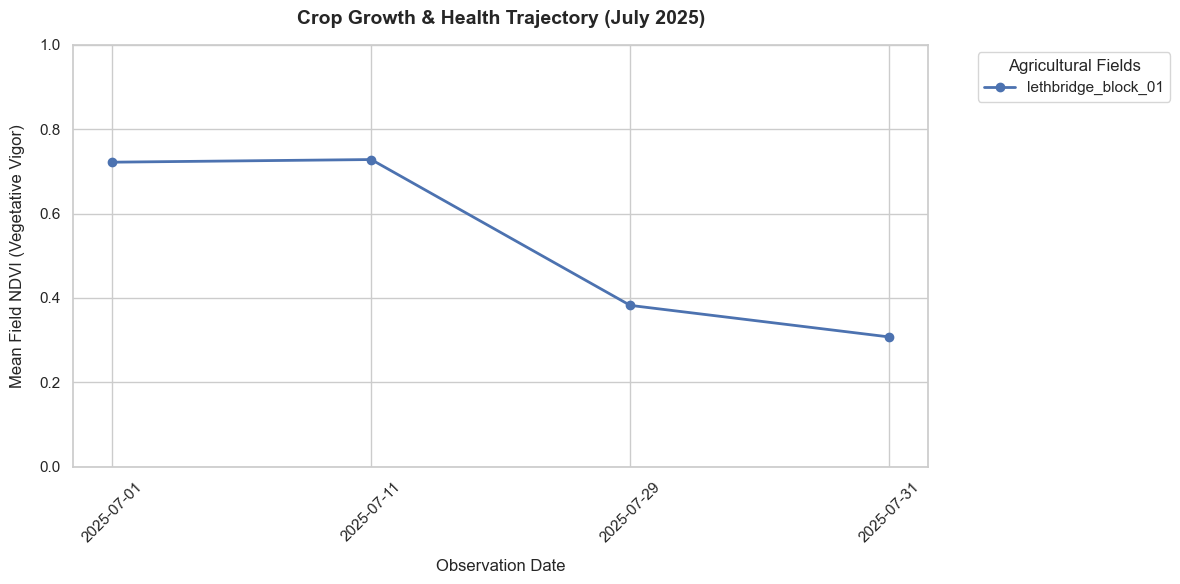

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Pivot the data frame so rows are dates, columns are your field names, and values are the mean NDVI
# This is the exact format needed to plot multiple lines effortlessly
plot_df = field_timeseries_df.pivot(index="date", columns="field_name", values="mean")

# Clean up the date index formatting for a nicer x-axis
plot_df.index = pd.to_datetime(plot_df.index).strftime('%Y-%m-%d')

# Plot every field as an individual line
for column in plot_df.columns:
    plt.plot(plot_df.index, plot_df[column], marker='o', linewidth=2, label=column)

# Style the graph
plt.title("Crop Growth & Health Trajectory (July 2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Observation Date", fontsize=12, labelpad=10)
plt.ylabel("Mean Field NDVI (Vegetative Vigor)", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, 1.0) # NDVI naturally ranges from -1 to 1, but living crops sit between 0 and 1
plt.legend(title="Agricultural Fields", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the payoff!
plt.show()

In [8]:
fields_gdf

,field_group_id,geometry
0,lethbridge_block_01,"POLYGON ((-113.11729 49.77104, -113.09566 49.7..."


Calculated Server Bounds (Meters):
XMin: -12592159.122715056
YMin: 6404386.272445671
XMax: -12589751.282129198
YMax: 6406718.01714711

Requesting image bytes directly from Canadian ImageServer REST API...
🎉 Array parsed successfully from memory buffer!

✅ Success! Ground-truth target array built.
Matrix Dimensions: (400, 400)
Official AAFC Crop IDs found: [ 34 110 122 133 146 153]


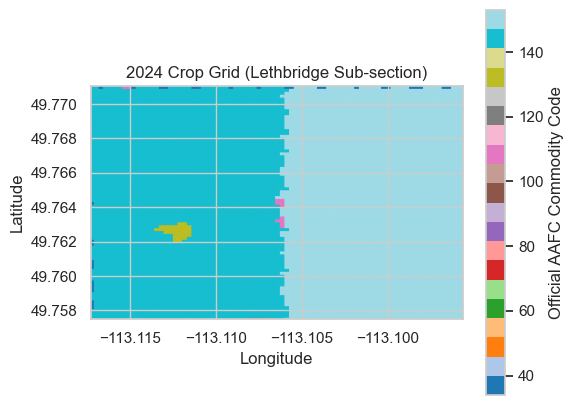

In [15]:
import io
import requests
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
from shapely.wkt import loads
from pyproj import Transformer

# The coordinates for our  test field in Lethbridge, Alberta. Lat/Lon to map out the polygon
polygon_wkt = (
    "POLYGON ((-113.11729 49.77104, -113.09566 49.77104, "
    "-113.09566 49.75751, -113.11729 49.75751, -113.11729 49.77104))"
)

#build the polygon
field_geometry = loads(polygon_wkt)
min_lon, min_lat, max_lon, max_lat = field_geometry.bounds

# Transform Lat/Lon (4326) into Web Mercator Meters (3857)
# projection math
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
xmin, ymin = transformer.transform(min_lon, min_lat)
xmax, ymax = transformer.transform(max_lon, max_lat)

# Use the "Export Image" endpoint from the agriculture canada website
stream_url = (
    "https://agriculture.canada.ca/imagery-images/rest/services/"
    "annual_crop_inventory/2024/ImageServer/exportImage"
)

#our parameters which are the polygon and other projection identifiers
# we want a tiff image format and to return an image file type
params = {
    "bbox": f"{xmin},{ymin},{xmax},{ymax}",
    "bboxSR": "3857",
    "imageSR": "3857",
    "format": "tiff",
    "f": "image"
}

print(f"Calculated Server Bounds (Meters):\nXMin: {xmin}\nYMin: {ymin}\nXMax: {xmax}\nYMax: {ymax}\n")
print("Requesting image bytes directly from Canadian ImageServer REST API...")

try:
    # Fetch the image bytes over HTTP
    response = requests.get(stream_url, params=params, timeout=30)
    response.raise_for_status()
    
    # 4. Wrap raw byte stream in an in-memory virtual file buffer
    image_bytes = io.BytesIO(response.content)
    
    # Pass the virtual file object to rioxarray
    with rioxarray.open_rasterio(image_bytes) as src:
        print("🎉 Array parsed successfully from memory buffer!")
        crop_grid = src.squeeze().compute().values

    # Clean out background nodata values (0)
    unique_codes = np.unique(crop_grid)
    unique_codes = unique_codes[unique_codes > 0]
    
    print("\n✅ Success! Ground-truth target array built.")
    print(f"Matrix Dimensions: {crop_grid.shape}")
    print(f"Official AAFC Crop IDs found: {unique_codes}")
    
    # 5. Plot the visual data array
    plt.figure(figsize=(6, 5))
    plt.imshow(crop_grid, cmap="tab20", extent=[min_lon, max_lon, min_lat, max_lat])
    plt.colorbar(label="Official AAFC Commodity Code")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("2024 Crop Grid (Lethbridge Sub-section)")
    plt.show()

except Exception as e:
    print(f"\nPipeline execution error: {e}")

In [24]:
for i in range(len(crop_grid)):
    for j in range(len(crop_grid[i])):
        print(crop_grid[i][j])

146
146
146
146
146
146
146
146
34
34
34
34
34
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
110
110
110
110
110
110
110
110
110
110
34
34
34
34
34
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
34
34
34
34
34
34
34
34
34
34
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
34
34
34
34
34
34
34
34
34
34
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
34
34
34
34
34
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
34
34
34
34
34
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
146
34
34
34
34
34
34
34
34
34
34
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
153
34
34
34
34
34
34
34
34
34
34
153
153
153
153
153
153
153
153
153
153
153
153


In [16]:
import folium
import numpy as np

# 1. Initialize an interactive map centered right over your Lethbridge coordinates
m = folium.Map(location=[49.764, -113.106], zoom_start=13, tiles="OpenStreetMap")

# 2. Add a Satellite layer to double check vegetation structures
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
    attr="Google Satellite",
    name="Google Satellite",
    overlay=False,
    control=True
).add_to(m)

# 3. Draw a bounding box showing EXACTLY where your data grid targets
# Red outline represents the exact margins of your (400, 400) matrix
folium.Rectangle(
    bounds=[[min_lat, min_lon], [max_lat, max_lon]],
    color="red",
    weight=3,
    fill=True,
    fill_opacity=0.1,
    popup="Owen & Matt's ML Training Target Area"
).add_to(m)

folium.LayerControl().add_to(m)

# Display the map right inside your Jupyter Notebook window
m